In [1]:
# Check GPU availability
!nvidia-smi

Thu Mar 12 05:30:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Install required packages
print("📦 Installing dependencies...")
!pip install -q transformers datasets accelerate peft tqdm pandas numpy scikit-learn matplotlib seaborn
print("✅ Dependencies installed!")

📦 Installing dependencies...
✅ Dependencies installed!


In [ ]:
# Cell 3: CENTRALIZED CONFIGURATION - SINGLE SOURCE OF TRUTH
# ============================================================================
# 🎯 Change all evaluation parameters HERE ONLY!
# All other cells dynamically reference this configuration.
# ============================================================================

import os

CONFIG = {
    # ============================================================
    # PATH CONFIGURATION
    # ============================================================
    "model_path": "/kaggle/input/datasets/abirashab/tuned-model",        # Your fine-tuned model dataset
    "data_path": "/kaggle/input/datasets/abirashab/train-test-val",            # Your test data dataset
    "test_file": "test.jsonl",                             # Test file name
    
    # ============================================================
    # EVALUATION SETTINGS
    # ============================================================
    "eval_limit": None,        # None = full dataset, or set number (e.g., 100, 500)
    "suspicious_ratio": 0.30,  # Ratio of suspicious samples when eval_limit is set (0.30 = 30%)
    "prioritize_shortest": True,  # Take shortest logs first when sampling
    "max_new_tokens": 512,     # Maximum tokens to generate per response
    "temperature": 0.7,        # Sampling temperature (0.0-1.0, higher = more random)
    "do_sample": True,         # Enable sampling (True for variety, False for deterministic)
    "top_p": 0.9,              # Nucleus sampling parameter
    
    # ============================================================
    # PROMPT CONFIGURATION
    # ============================================================
    "max_input_chars": 6000,   # Maximum input characters (truncate longer inputs)
    "max_length_tokens": 3072, # Maximum tokens for input + prompt
    
    # ============================================================
    # OUTPUT SETTINGS
    # ============================================================
    "show_examples": 10,       # Number of examples to display during evaluation
    "save_results": True,      # Save results to CSV
    "results_file": "evaluation_results.csv",
    "metrics_file": "metrics_summary.csv",
}

# Auto-derived paths
CONFIG["test_file_path"] = f"{CONFIG['data_path']}/{CONFIG['test_file']}"

# ============================================================
# DISPLAY CONFIGURATION
# ============================================================
print("="*80)
print("📋 EVALUATION CONFIGURATION")
print("="*80)

print(f"\n📂 Paths:")
print(f"   Model: {CONFIG['model_path']}")
print(f"   Test data: {CONFIG['test_file_path']}")

print(f"\n🎯 Evaluation Settings:")
if CONFIG['eval_limit'] is None:
    print(f"   Eval limit: Full dataset (all examples)")
else:
    print(f"   Eval limit: {CONFIG['eval_limit']:,} examples")
    print(f"   Suspicious ratio: {CONFIG['suspicious_ratio']*100:.0f}%")
    print(f"   Prioritize shortest: {CONFIG['prioritize_shortest']}")
print(f"   Max new tokens: {CONFIG['max_new_tokens']}")
print(f"   Temperature: {CONFIG['temperature']}")
print(f"   Sampling: {CONFIG['do_sample']}")
print(f"   Top-p: {CONFIG['top_p']}")

print(f"\n📊 Prompt Settings:")
print(f"   Max input chars: {CONFIG['max_input_chars']:,}")
print(f"   Max length tokens: {CONFIG['max_length_tokens']:,}")

print(f"\n💾 Output Settings:")
print(f"   Show examples: {CONFIG['show_examples']}")
print(f"   Save results: {CONFIG['save_results']}")
if CONFIG['save_results']:
    print(f"   Results file: {CONFIG['results_file']}")
    print(f"   Metrics file: {CONFIG['metrics_file']}")

print("="*80)

# Verify paths exist
if os.path.exists(CONFIG['model_path']):
    print(f"✅ Model found: {len(os.listdir(CONFIG['model_path']))} files")
else:
    print(f"❌ Model not found at {CONFIG['model_path']}")
    print("   Please upload your fine_tuned_model as a Kaggle dataset")

if os.path.exists(CONFIG['test_file_path']):
    print(f"✅ Test file found")
else:
    print(f"❌ Test file not found at {CONFIG['test_file_path']}")
    print("   Please add your test dataset to Kaggle")
print("✅ Configuration loaded! All cells will use these settings.")
print("="*80)

📋 EVALUATION CONFIGURATION

📂 Paths:
   Model: /kaggle/input/datasets/abirashab/tuned-model
   Test data: /kaggle/input/datasets/abirashab/train-test-val/test.jsonl

🎯 Evaluation Settings:
   Eval limit: 2,000 examples
   Suspicious ratio: 30%
   Prioritize shortest: True
   Max new tokens: 512
   Temperature: 0.7
   Sampling: True
   Top-p: 0.9

📊 Prompt Settings:
   Max input chars: 6,000
   Max length tokens: 3,072

💾 Output Settings:
   Show examples: 10
   Save results: True
   Results file: evaluation_results.csv
   Metrics file: metrics_summary.csv
✅ Model found: 11 files
✅ Test file found
✅ Configuration loaded! All cells will use these settings.


In [4]:
# Cell 4: Load the fine-tuned model (using CONFIG)
print("🔄 Loading fine-tuned model...\n")

from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model = AutoModelForCausalLM.from_pretrained(
    CONFIG["model_path"],
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_path"], trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

model.eval()  # Set to evaluation mode

print(f"✅ Model loaded from: {CONFIG['model_path']}")
print(f"📊 GPU Memory: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"📊 Model device: {model.device}")

🔄 Loading fine-tuned model...



config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!
2026-03-12 05:30:55.422362: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773293455.575421      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773293455.618354      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773293455.977740      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773293455.977773      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773293455.977776      24

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

✅ Model loaded from: /kaggle/input/datasets/abirashab/tuned-model
📊 GPU Memory: 1.40 GB
📊 Model device: cuda:0


In [5]:
# Cell 5: Load test dataset (using CONFIG)
print("🔄 Loading test dataset...\n")

from datasets import load_dataset
import json

test_dataset = load_dataset('json', data_files={'test': CONFIG["test_file_path"]})['test']

print(f"✅ Test dataset loaded: {len(test_dataset):,} examples")
print(f"\n📋 Dataset columns: {test_dataset.column_names}")

# Display sample entry with NEW format
print(f"\n" + "="*80)
print("📋 SAMPLE TEST ENTRY (NEW FORMAT)")
print("="*80)

sample = test_dataset[0]

print(f"\n1️⃣ INSTRUCTION:")
print(f"   {sample['instruction']}")

print(f"\n2️⃣ INPUT (JSON with metadata + logs):")
# Parse input to show structure
try:
    input_data = json.loads(sample['input'])
    print(f"   Metadata:")
    print(f"     - session_id: {input_data.get('metadata', {}).get('session_id', 'N/A')}")
    print(f"     - chunk_index: {input_data.get('metadata', {}).get('chunk_index', 'N/A')}")
    print(f"     - number_of_events: {input_data.get('metadata', {}).get('number_of_events', 'N/A')}")
    print(f"   Logs: {len(input_data.get('logs', []))} events")
    print(f"   First log: {str(input_data.get('logs', [{}])[0])[:150]}...")
except:
    print(f"   {sample['input'][:200]}... [Raw text, {len(sample['input'])} chars total]")

print(f"\n3️⃣ OUTPUT (Detailed Analysis):")
output_preview = sample['output'][:400]
print(f"   {output_preview}...")

# Detect status
from re import search
is_normal = 'normal activity detected' in sample['output'].lower()
is_suspicious = 'security alert' in sample['output'].lower()

print(f"\n📊 Status: {'NORMAL' if is_normal else 'SUSPICIOUS' if is_suspicious else 'UNKNOWN'}")
print(f"   Output length: {len(sample['output'])} characters")
print(f"   Has field references: {'Referenced Fields' in sample['output']}")
print(f"   Has MITRE techniques: {bool(search(r'T\d{4}', sample['output']))}")
print(f"   Has severity levels: {'Severity' in sample['output'] or 'CRITICAL' in sample['output']}")

print("="*80)
print("✅ Dataset structure verified - matches NEW training format")
print("="*80)


🔄 Loading test dataset...



Generating test split: 0 examples [00:00, ? examples/s]

✅ Test dataset loaded: 10,606 examples

📋 Dataset columns: ['instruction', 'input', 'output']

📋 SAMPLE TEST ENTRY (NEW FORMAT)

1️⃣ INSTRUCTION:
   Analyze this session log chunk and determine if it contains normal or suspicious activity. If suspicious, identify all MITRE ATT&CK techniques and explain why.

2️⃣ INPUT (JSON with metadata + logs):
   Metadata:
     - session_id: 20250918_233300
     - chunk_index: 909
     - number_of_events: 7
   Logs: 7 events
   First log: {'timestamp': '2025-09-18T17:40:21.817Z', 'event_type': 'network', 'length': 1514, 'summary': 'Ether / IP / TCP 23.212.0.52:https > 10.10.13.16:59653 ...

3️⃣ OUTPUT (Detailed Analysis):
   **Normal Activity Detected**: 7 events analyzed (7 Network). No malicious indicators found.

**Normal Patterns Observed:**
- Standard network traffic on ports: 443

**No Malicious Indicators:**
- No C2 beaconing patterns (no small periodic packets to external IPs)
- No connections to high-risk ports (e.g., 4444, 8080, 31337)

**

In [6]:
# UTILITY FUNCTIONS FOR EVALUATION
print("🔄 Defining utility functions for evaluation...\n")

import re
import torch

def generate_response(model, tokenizer, instruction, input_text, max_new_tokens=None):
    """
    Generate a response using the SAME format as training data.
    
    Training data format:
    - instruction: "Analyze this session log chunk and determine if it contains normal or suspicious activity..."
    - input: JSON string with metadata + logs
    - output: Detailed analysis (Normal Activity Detected OR SECURITY ALERT with breakdown)
    """
    
    # Use CONFIG values
    if max_new_tokens is None:
        max_new_tokens = CONFIG["max_new_tokens"]
    
    # TRUNCATE INPUT IF TOO LONG
    MAX_INPUT_CHARS = CONFIG["max_input_chars"]
    
    if len(input_text) > MAX_INPUT_CHARS:
        input_text = input_text[:MAX_INPUT_CHARS] + "... [truncated]"
    
    # Build prompt matching training data format
    # Format: instruction + "\n\n" + input + "\n\nAnalysis:\n"
    prompt = f"{instruction}\n\n{input_text}\n\nAnalysis:\n"
    
    # Tokenize with max_length to prevent truncation issues
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=CONFIG["max_length_tokens"])
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=CONFIG["temperature"],
            do_sample=CONFIG["do_sample"],
            top_p=CONFIG["top_p"],
            pad_token_id=tokenizer.eos_token_id
        )
    
    # Decode only the generated part (remove the prompt)
    generated_text = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    return generated_text.strip()


def extract_status_label(text):
    """
    Extract Normal/Suspicious/Unknown from NEW model output format.
    
    NEW format:
    - Normal: "**Normal Activity Detected**: X events analyzed..."
    - Suspicious: "**SECURITY ALERT**: X out of X events show malicious activity..."
    """
    if not text or not isinstance(text, str):
        return 'UNKNOWN'
    
    text_lower = text.lower()
    
    # Check for new format markers (more robust checking)
    # Normal indicators
    normal_markers = [
        'normal activity detected',
        '**normal activity',
        'no malicious',
        'no suspicious indicators',
        'standard activity',
        'routine activity'
    ]
    
    # Suspicious indicators  
    suspicious_markers = [
        'security alert',
        '**security alert',
        'suspicious activity',
        'malicious activity',
        'attack detected',
        'threat detected'
    ]
    
    # Check suspicious first (stronger signal)
    for marker in suspicious_markers:
        if marker in text_lower:
            return 'SUSPICIOUS'
    
    # Then check normal
    for marker in normal_markers:
        if marker in text_lower:
            return 'NORMAL'
    
    # Fallback: Check for old format (for backward compatibility)
    if 'status: normal' in text_lower or 'status:normal' in text_lower:
        return 'NORMAL'
    elif 'status: suspicious' in text_lower or 'status:suspicious' in text_lower:
        return 'SUSPICIOUS'
    
    return 'UNKNOWN'


def extract_technique_id(text):
    """Extract MITRE technique ID from text (e.g., T1234, T1234.001)"""
    match = re.search(r'T\d{4}(?:\.\d{3})?', text.upper())
    return match.group(0) if match else None


def calculate_exact_match(pred, target):
    """Calculate exact match accuracy."""
    return 1.0 if pred.strip().lower() == target.strip().lower() else 0.0


def calculate_partial_match(pred, target):
    """Calculate partial match (keyword overlap)."""
    pred_lower = pred.strip().lower()
    target_lower = target.strip().lower()
    
    # Check if major keywords from target appear in prediction
    target_words = set(target_lower.split())
    pred_words = set(pred_lower.split())
    
    if len(target_words) == 0:
        return 0.0
    
    overlap = len(target_words.intersection(pred_words))
    return overlap / len(target_words)


def calculate_f1_score(pred, target):
    """Calculate F1 score based on word overlap."""
    pred_words = set(pred.strip().lower().split())
    target_words = set(target.strip().lower().split())
    
    if len(pred_words) == 0 or len(target_words) == 0:
        return 0.0
    
    overlap = len(pred_words.intersection(target_words))
    precision = overlap / len(pred_words) if len(pred_words) > 0 else 0.0
    recall = overlap / len(target_words) if len(target_words) > 0 else 0.0
    
    if precision + recall == 0:
        return 0.0
    
    f1 = 2 * (precision * recall) / (precision + recall)
    return f1


print("✅ Utility functions defined:")
print("   - generate_response() - Generate model predictions")
print("   - extract_status_label() - Extract NORMAL/SUSPICIOUS/UNKNOWN")
print("   - extract_technique_id() - Extract MITRE technique IDs")
print("   - calculate_exact_match() - Binary match scorer")
print("   - calculate_partial_match() - Word overlap scorer")
print("   - calculate_f1_score() - Word-level F1 scorer")
print("\n" + "="*80)


🔄 Defining utility functions for evaluation...

✅ Utility functions defined:
   - generate_response() - Generate model predictions
   - extract_status_label() - Extract NORMAL/SUSPICIOUS/UNKNOWN
   - extract_technique_id() - Extract MITRE technique IDs
   - calculate_exact_match() - Binary match scorer
   - calculate_partial_match() - Word overlap scorer
   - calculate_f1_score() - Word-level F1 scorer



In [7]:
# TEST BASE MODEL WITH NEW TRAINING DATA FORMAT
print("🔄 Loading BASE Qwen2.5-1.5B-Instruct model (not fine-tuned)...\n")

from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
import re
import json

# Load the original base model
base_model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-1.5B-Instruct",
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

base_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct", trust_remote_code=True)
base_tokenizer.pad_token = base_tokenizer.eos_token

base_model.eval()

print(f"✅ Base model loaded")
print(f"📊 GPU Memory: {torch.cuda.memory_allocated() / 1024**3:.2f} GB\n")

print("="*80)
print("🎯 TESTING BASE MODEL WITH NEW TRAINING DATA FORMAT")
print("="*80)
print("Using the SAME prompt format as training data:\n")
print("instruction + '\\n\\n' + input + '\\n\\nAnalysis:\\n'\n")

# Get test example
example = test_dataset[0]

# Build prompt matching training data format
instruction = example['instruction']
input_text = example['input']

# Truncate input if too long
MAX_INPUT_CHARS = CONFIG['max_input_chars']
if len(input_text) > MAX_INPUT_CHARS:
    input_text = input_text[:MAX_INPUT_CHARS] + "... [truncated]"
    print(f"⚠️ Input truncated to {MAX_INPUT_CHARS:,} chars")

# Format: instruction + "\n\n" + input + "\n\nAnalysis:\n"
prompt = f"{instruction}\n\n{input_text}\n\nAnalysis:\n"

print(f"📊 PROMPT LENGTH: {len(prompt):,} characters")
print(f"📋 Instruction: {instruction}")
print(f"📋 Input (first 200 chars): {input_text[:200]}...")
print(f"\n📋 EXPECTED OUTPUT (first 300 chars):")
print(f"{example['output'][:300]}...\n")

# Tokenize
inputs = base_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=CONFIG['max_length_tokens'])
inputs = {k: v.to(base_model.device) for k, v in inputs.items()}

print(f"📊 After tokenization: {inputs['input_ids'].shape[1]} tokens")

if inputs['input_ids'].shape[1] >= CONFIG['max_length_tokens']:
    print(f"⚠️ WARNING: Prompt was truncated to fit {CONFIG['max_length_tokens']} tokens!")
else:
    print(f"✅ No truncation - full input preserved!")

# Generate
print("\n🚀 Generating response...")
with torch.no_grad():
    outputs = base_model.generate(
        **inputs,
        max_new_tokens=CONFIG['max_new_tokens'],
        temperature=CONFIG['temperature'],
        do_sample=CONFIG['do_sample'],
        top_p=CONFIG['top_p'],
        pad_token_id=base_tokenizer.eos_token_id
    )

# Decode
generated_text = base_tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

print(f"\n" + "="*80)
print(f"🤖 BASE MODEL PREDICTED:")
print("="*80)
print(generated_text[:500])
if len(generated_text) > 500:
    print("... [truncated for display]")
print("="*80)

# Check if it matches NEW format
has_normal = 'normal activity detected' in generated_text.lower() or '**normal' in generated_text.lower()
has_security_alert = 'security alert' in generated_text.lower() or '**security alert' in generated_text.lower()
has_suspicious = 'suspicious' in generated_text.lower()

print(f"\n✅ Format Check (NEW format):")
print(f"   Contains '**Normal Activity Detected**': {has_normal}")
print(f"   Contains '**SECURITY ALERT**': {has_security_alert}")
print(f"   Contains 'suspicious': {has_suspicious}")

detected_status = extract_status_label(generated_text)
expected_status = extract_status_label(example['output'])

print(f"\n📊 Status Detection:")
print(f"   Expected: {expected_status}")
print(f"   Predicted: {detected_status}")
print(f"   Match: {detected_status == expected_status}")

if detected_status == 'UNKNOWN':
    print("\n⚠️ Base model output doesn't match NEW training format.")
    print("   This is EXPECTED - base model wasn't trained on this format.")
    print("   Fine-tuned model should produce proper format.")
else:
    print("\n✅ Base model produced recognizable output!")

# Clean up to free memory
del base_model
del base_tokenizer
torch.cuda.empty_cache()
print("\n✅ Base model unloaded to free memory")


🔄 Loading BASE Qwen2.5-1.5B-Instruct model (not fine-tuned)...



tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Base model loaded
📊 GPU Memory: 2.88 GB

🎯 TESTING BASE MODEL WITH NEW TRAINING DATA FORMAT
Using the SAME prompt format as training data:

instruction + '\n\n' + input + '\n\nAnalysis:\n'

📊 PROMPT LENGTH: 2,786 characters
📋 Instruction: Analyze this session log chunk and determine if it contains normal or suspicious activity. If suspicious, identify all MITRE ATT&CK techniques and explain why.
📋 Input (first 200 chars): {"metadata": {"session_id": "20250918_233300", "chunk_index": 909, "start_time": "2025-09-18T17:40:21.817Z", "end_time": "2025-09-18T17:40:21.817Z", "number_of_events": 7}, "logs": [{"timestamp": "202...

📋 EXPECTED OUTPUT (first 300 chars):
**Normal Activity Detected**: 7 events analyzed (7 Network). No malicious indicators found.

**Normal Patterns Observed:**
- Standard network traffic on ports: 443

**No Malicious Indicators:**
- No C2 beaconing patterns (no small periodic packets to external IPs)
- No connections to high-risk ports...

📊 After tokenization: 152

In [8]:
# TEST FINE-TUNED MODEL WITH NEW FORMAT
print("🔄 Testing FINE-TUNED model with NEW training data format...\n")

import re
import json

print("="*80)
print("🎯 TESTING FINE-TUNED MODEL (NEW FORMAT)")
print("="*80)
print("Using the SAME prompt structure as training data.\n")

# Get the same test example
example = test_dataset[0]

# Build prompt matching training data format
instruction = example['instruction']
input_text = example['input']

# Truncate input if too long
MAX_INPUT_CHARS = CONFIG['max_input_chars']
if len(input_text) > MAX_INPUT_CHARS:
    input_text = input_text[:MAX_INPUT_CHARS] + "... [truncated]"
    print(f"⚠️ Input truncated to {MAX_INPUT_CHARS:,} chars")

# Format: instruction + "\n\n" + input + "\n\nAnalysis:\n"
prompt = f"{instruction}\n\n{input_text}\n\nAnalysis:\n"

print(f"📊 PROMPT LENGTH: {len(prompt):,} characters")
print(f"📋 Instruction: {instruction}")
print(f"📋 Input (first 200 chars): {input_text[:200]}...")
print(f"\n📋 EXPECTED OUTPUT (first 300 chars):")
print(f"{example['output'][:300]}...\n")

# Tokenize
inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=CONFIG['max_length_tokens'])
inputs = {k: v.to(model.device) for k, v in inputs.items()}

print(f"📊 After tokenization: {inputs['input_ids'].shape[1]} tokens")

if inputs['input_ids'].shape[1] >= CONFIG['max_length_tokens']:
    print(f"⚠️ WARNING: Prompt was truncated to fit {CONFIG['max_length_tokens']} tokens!")
else:
    print(f"✅ No truncation - full input preserved!")

# Generate with fine-tuned model
print("\n🚀 Generating response with FINE-TUNED model...")
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=CONFIG['max_new_tokens'],
        temperature=CONFIG['temperature'],
        do_sample=CONFIG['do_sample'],
        top_p=CONFIG['top_p'],
        pad_token_id=tokenizer.eos_token_id
    )

# Decode
generated_text = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

print(f"\n" + "="*80)
print(f"🤖 FINE-TUNED MODEL PREDICTED:")
print("="*80)
print(generated_text[:500])
if len(generated_text) > 500:
    print("... [truncated for display]")
print("="*80)

print(f"\n" + "="*80)
print(f"📊 EXPECTED OUTPUT:")
print("="*80)
print(example['output'][:500])
if len(example['output']) > 500:
    print("... [truncated for display]")
print("="*80)

# Check if it matches NEW format
has_normal = 'normal activity detected' in generated_text.lower() or '**normal' in generated_text.lower()
has_security_alert = 'security alert' in generated_text.lower() or '**security alert' in generated_text.lower()
has_suspicious = 'suspicious' in generated_text.lower()

print(f"\n✅ Format Check (NEW format):")
print(f"   Contains '**Normal Activity Detected**': {has_normal}")
print(f"   Contains '**SECURITY ALERT**': {has_security_alert}")
print(f"   Contains 'suspicious': {has_suspicious}")

detected_status = extract_status_label(generated_text)
expected_status = extract_status_label(example['output'])

print(f"\n📊 Status Detection:")
print(f"   Expected: {expected_status}")
print(f"   Predicted: {detected_status}")
print(f"   Match: {'✅ YES' if detected_status == expected_status else '❌ NO'}")

if detected_status == expected_status:
    print("\n🎉 SUCCESS! Fine-tuned model is outputting the correct format!")
    print("   The model has learned the NEW detailed analysis format.")
else:
    print("\n⚠️ Model output doesn't match expected format.")
    print("   Possible causes:")
    print("   - Model needs more training")
    print("   - Input was truncated too much")
    print("   - Temperature/sampling settings too high")

# Check for field references (key feature of new format)
has_field_refs = 'referenced fields' in generated_text.lower() or 'destinationip=' in generated_text.lower()
has_mitre = bool(re.search(r'T\d{4}', generated_text))
has_severity = 'severity' in generated_text.lower() or 'critical' in generated_text.lower() or 'high' in generated_text.lower()

print(f"\n📋 NEW Format Features Check:")
print(f"   Field references (e.g., 'DestinationIp=X'): {has_field_refs}")
print(f"   MITRE techniques (e.g., 'T1234'): {has_mitre}")
print(f"   Severity levels: {has_severity}")

if has_field_refs and has_mitre:
    print("\n✅ Model is generating field-specific analysis!")
elif detected_status != 'UNKNOWN':
    print("\n⚠️ Model detected status but missing detailed analysis features")
else:
    print("\n❌ Model needs retraining with NEW format data")


🔄 Testing FINE-TUNED model with NEW training data format...

🎯 TESTING FINE-TUNED MODEL (NEW FORMAT)
Using the SAME prompt structure as training data.

📊 PROMPT LENGTH: 2,786 characters
📋 Instruction: Analyze this session log chunk and determine if it contains normal or suspicious activity. If suspicious, identify all MITRE ATT&CK techniques and explain why.
📋 Input (first 200 chars): {"metadata": {"session_id": "20250918_233300", "chunk_index": 909, "start_time": "2025-09-18T17:40:21.817Z", "end_time": "2025-09-18T17:40:21.817Z", "number_of_events": 7}, "logs": [{"timestamp": "202...

📋 EXPECTED OUTPUT (first 300 chars):
**Normal Activity Detected**: 7 events analyzed (7 Network). No malicious indicators found.

**Normal Patterns Observed:**
- Standard network traffic on ports: 443

**No Malicious Indicators:**
- No C2 beaconing patterns (no small periodic packets to external IPs)
- No connections to high-risk ports...

📊 After tokenization: 1525 tokens
✅ No truncation - full input pr

In [ ]:
# Run evaluation
print("🚀 Running evaluation on test set...\n")

from tqdm import tqdm
import time
import numpy as np

# Determine sample size (using CONFIG)
if CONFIG["eval_limit"] is None:
    eval_samples = test_dataset
    print(f"Evaluating on FULL test set: {len(eval_samples):,} examples")
else:
    # STRATIFIED SAMPLING: Get balanced suspicious/normal samples with shortest logs first
    print(f"📊 Stratified sampling: {CONFIG['suspicious_ratio']*100:.0f}% suspicious, {(1-CONFIG['suspicious_ratio'])*100:.0f}% normal")
    
    # Add length to each sample and extract status
    indexed_data = []
    for i in range(len(test_dataset)):
        sample = test_dataset[i]
        status = extract_status_label(sample['output'])
        length = len(sample['input'])
        indexed_data.append({'index': i, 'status': status, 'length': length})
    
    # Separate by status
    suspicious_samples = [s for s in indexed_data if s['status'] == 'SUSPICIOUS']
    normal_samples = [s for s in indexed_data if s['status'] == 'NORMAL']
    unknown_samples = [s for s in indexed_data if s['status'] == 'UNKNOWN']
    
    print(f"   Available: {len(suspicious_samples)} suspicious, {len(normal_samples)} normal, {len(unknown_samples)} unknown")
    
    # Debug: Show a sample if all are unknown
    if len(suspicious_samples) == 0 and len(normal_samples) == 0:
        print(f"\n⚠️ ERROR: No samples classified as NORMAL or SUSPICIOUS!")
        print(f"   All {len(unknown_samples)} samples returned UNKNOWN status.")
        print(f"\n   Sample output from test data (first 300 chars):")
        if len(test_dataset) > 0:
            print(f"   {test_dataset[0]['output'][:300]}...")
        print(f"\n   This means extract_status_label() cannot detect the format.")
        print(f"   Check if test data uses the expected NEW format.")
        raise ValueError("Status extraction failed - check test data format!")
    
    # Sort by length (shortest first) if enabled
    if CONFIG["prioritize_shortest"]:
        suspicious_samples.sort(key=lambda x: x['length'])
        normal_samples.sort(key=lambda x: x['length'])
        print(f"   Prioritizing shortest logs")
    
    # Calculate target counts
    target_suspicious = int(CONFIG["eval_limit"] * CONFIG["suspicious_ratio"])
    target_normal = CONFIG["eval_limit"] - target_suspicious
    
    # Take samples (limited by availability)
    selected_suspicious = suspicious_samples[:min(target_suspicious, len(suspicious_samples))]
    selected_normal = normal_samples[:min(target_normal, len(normal_samples))]
    
    # Combine and extract indices
    selected_indices = [s['index'] for s in selected_suspicious + selected_normal]
    
    print(f"   Selected: {len(selected_suspicious)} suspicious, {len(selected_normal)} normal")
    
    if CONFIG["prioritize_shortest"]:
        min_len_susp = min([s['length'] for s in selected_suspicious]) if selected_suspicious else 0
        max_len_susp = max([s['length'] for s in selected_suspicious]) if selected_suspicious else 0
        min_len_norm = min([s['length'] for s in selected_normal]) if selected_normal else 0
        max_len_norm = max([s['length'] for s in selected_normal]) if selected_normal else 0
        print(f"   Suspicious lengths: {min_len_susp:,} - {max_len_susp:,} chars")
        print(f"   Normal lengths: {min_len_norm:,} - {max_len_norm:,} chars")
    
    # Select from dataset
    eval_samples = test_dataset.select(selected_indices)
    print(f"\n✅ Evaluating on {len(eval_samples):,} stratified samples (out of {len(test_dataset):,})")

print(f"This may take a while...\n")

results = []
exact_matches = 0
partial_match_scores = []
f1_scores = []

start_time = time.time()

for i, example in enumerate(tqdm(eval_samples, desc="Evaluating")):
    # Generate prediction
    prediction = generate_response(
        model,
        tokenizer,
        example['instruction'],
        example['input'],
        max_new_tokens=CONFIG["max_new_tokens"]
    )
    
    # Calculate metrics
    exact_match = calculate_exact_match(prediction, example['output'])
    partial_match = calculate_partial_match(prediction, example['output'])
    f1 = calculate_f1_score(prediction, example['output'])
    
    exact_matches += exact_match
    partial_match_scores.append(partial_match)
    f1_scores.append(f1)
    
    # Store result
    results.append({
        'index': i,
        'instruction': example['instruction'],
        'input': example['input'],
        'expected': example['output'],
        'predicted': prediction,
        'exact_match': exact_match,
        'partial_match': partial_match,
        'f1_score': f1
    })
    
    # Show examples based on CONFIG during evaluation
    if CONFIG["show_examples"] > 0 and i < CONFIG["show_examples"]:
        print(f"\n{'='*80}")
        print(f"Example {i+1}:")
        print(f"Instruction: {example['instruction'][:80]}...")
        print(f"Input: {example['input'][:80]}...")
        print(f"Expected: {example['output'][:200]}...")
        print(f"Predicted: {prediction[:200]}...")
        print(f"Metrics: Exact={exact_match}, Partial={partial_match:.2f}, F1={f1:.2f}")
        print(f"{'='*80}\n")

# Calculate elapsed time
elapsed = time.time() - start_time

# Show completion message
if len(eval_samples) > 0:
    print(f"\n{'='*80}")
    print(f"✅ Evaluation completed in {elapsed/60:.2f} minutes ({elapsed/len(eval_samples):.2f} sec/example)")
    print(f"{'='*80}")
else:
    print(f"\n⚠️ No samples evaluated! Check CONFIG['eval_limit'] and status extraction.")

🚀 Running evaluation on test set...

📊 Stratified sampling: 30% suspicious, 70% normal
   Available: 958 suspicious, 9648 normal, 0 unknown
   Prioritizing shortest logs
   Selected: 600 suspicious, 1400 normal
   Suspicious lengths: 564 - 2,712 chars
   Normal lengths: 827 - 2,423 chars

✅ Evaluating on 2,000 stratified samples (out of 10,606)
This may take a while...



Evaluating:   0%|          | 1/2000 [00:12<6:52:31, 12.38s/it]


Example 1:
Instruction: Analyze this session log chunk and determine if it contains normal or suspicious...
Input: {"metadata": {"session_id": "20250720_204132", "chunk_index": 73, "start_time": ...
Expected: **SECURITY ALERT**: 0 out of 1 events show malicious activity (Severity: LOW)

**Suspicious Events Detected:**...
Predicted: **Normal Activity Detected**: 1 events analyzed. No malicious indicators found.

**Normal Patterns Observed:**
- Standard system operations by process: 7za.exe

**No Malicious Indicators:**
- No suspi...
Metrics: Exact=0.0, Partial=0.36, F1=0.12



Evaluating:   0%|          | 2/2000 [00:26<7:22:57, 13.30s/it]


Example 2:
Instruction: Analyze this session log chunk and determine if it contains normal or suspicious...
Input: {"metadata": {"session_id": "20251025_142600", "chunk_index": 247, "start_time":...
Expected: **SECURITY ALERT**: 4 out of 4 events show malicious activity (Severity: CRITICAL)

**Suspicious Events Detected:**

1. [Network] EventID 3 at 2025-10-25T08:46:10.006Z - CRITICAL SEVERITY
   Analysis:...
Predicted: **Normal Activity Detected**: 4 events analyzed (4 Network). No malicious indicators found.

**Normal Patterns Observed:**
- Standard network traffic on ports: 0, 24547

**No Malicious Indicators:**
-...
Metrics: Exact=0.0, Partial=0.21, F1=0.14



...


Example 9:
Instruction: Analyze this session log chunk and determine if it contains normal or suspicious...
Input: {"metadata": {"session_id": "20251025_142600", "chunk_index": 118, "start_time":...
Expected: **SECURITY ALERT**: 0 out of 7 events show malicious activity (Severity: LOW)

**Suspicious Events Detected:**...
Predicted: **Normal Activity Detected**: 7 events analyzed (7 Network). No malicious indicators found.

**Normal Patterns Observed:**
- Standard network traffic on ports: 55106

**No Malicious Indicators:**
- No...
Metrics: Exact=0.0, Partial=0.29, F1=0.11



Evaluating:   0%|          | 10/2000 [02:07<6:10:13, 11.16s/it]


Example 10:
Instruction: Analyze this session log chunk and determine if it contains normal or suspicious...
Input: {"metadata": {"session_id": "20251025_142600", "chunk_index": 117, "start_time":...
Expected: **SECURITY ALERT**: 1 out of 7 events show malicious activity (Severity: HIGH)

**Suspicious Events Detected:**

1. [Network] EventID 3 at 2025-10-25T08:43:15.268Z - HIGH SEVERITY
   Analysis: Network...
Predicted: **Normal Activity Detected**: 7 events analyzed (7 Network). No malicious indicators found.

**Normal Patterns Observed:**
- Standard network traffic on ports: 55106

**No Malicious Indicators:**
- No...
Metrics: Exact=0.0, Partial=0.16, F1=0.15



Evaluating: 100%|██████████| 2000/2000 [8:23:48<00:00, 15.11s/it]


✅ Evaluation completed in 503.81 minutes (15.11 sec/example)


In [10]:
# TOKEN USAGE STATISTICS
# Note: This cell is optional - it shows token usage statistics if collected
print("\n" + "="*80)
print("📊 BASIC EVALUATION STATISTICS")
print("="*80 + "\n")

import numpy as np

# Calculate input length statistics from results
input_lengths = [len(r['input']) for r in results]

print(f"Total examples processed: {len(results)}")
print(f"\n📈 Input Length Statistics (characters):")
print(f"   Min length:     {min(input_lengths):,}")
print(f"   Max length:     {max(input_lengths):,}")
print(f"   Average length: {np.mean(input_lengths):,.0f}")
print(f"   Median length:  {np.median(input_lengths):,.0f}")

# Show truncation stats
truncated_count = sum(1 for length in input_lengths if length > CONFIG['max_input_chars'])
print(f"\n📊 Input Truncation:")
print(f"   Max allowed chars: {CONFIG['max_input_chars']:,}")
if truncated_count > 0:
    print(f"   ⚠️ Truncated inputs: {truncated_count} / {len(results)} ({truncated_count/len(results)*100:.1f}%)")
else:
    print(f"   ✅ No truncation needed - all inputs within limit")

# Prediction length statistics
pred_lengths = [len(r['predicted']) for r in results]
print(f"\n📈 Prediction Length Statistics (characters):")
print(f"   Min length:     {min(pred_lengths):,}")
print(f"   Max length:     {max(pred_lengths):,}")
print(f"   Average length: {np.mean(pred_lengths):,.0f}")
print(f"   Median length:  {np.median(pred_lengths):,.0f}")

print("="*80)



📊 BASIC EVALUATION STATISTICS

Total examples processed: 2000

📈 Input Length Statistics (characters):
   Min length:     564
   Max length:     2,712
   Average length: 2,383
   Median length:  2,323

📊 Input Truncation:
   Max allowed chars: 6,000
   ✅ No truncation needed - all inputs within limit

📈 Prediction Length Statistics (characters):
   Min length:     450
   Max length:     2,659
   Average length: 761
   Median length:  631


In [11]:
# Calculate comprehensive metrics - FIXED VERSION
print("\n" + "="*80)
print("📊 CALCULATING COMPREHENSIVE METRICS")
print("="*80 + "\n")

import numpy as np
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix,
    classification_report
)
import pandas as pd
from collections import Counter

# FIXED: Extract status labels (Normal/Suspicious) instead of just MITRE IDs
y_true_status = [extract_status_label(r['expected']) for r in results]
y_pred_status = [extract_status_label(r['predicted']) for r in results]

print("="*80)
print("🎯 STATUS CLASSIFICATION METRICS (Normal vs Suspicious)")
print("="*80 + "\n")

# Get unique status labels
unique_status_labels = sorted(list(set(y_true_status + y_pred_status)))
print(f"📋 Status labels found: {unique_status_labels}\n")

# Print label distribution
print(f"Expected label distribution:")
print(f"  {Counter(y_true_status)}\n")
print(f"Predicted label distribution:")
print(f"  {Counter(y_pred_status)}\n")

# Calculate status classification metrics
status_accuracy = accuracy_score(y_true_status, y_pred_status)
status_precision_macro = precision_score(y_true_status, y_pred_status, average='macro', zero_division=0)
status_precision_weighted = precision_score(y_true_status, y_pred_status, average='weighted', zero_division=0)
status_recall_macro = recall_score(y_true_status, y_pred_status, average='macro', zero_division=0)
status_recall_weighted = recall_score(y_true_status, y_pred_status, average='weighted', zero_division=0)
status_f1_macro = f1_score(y_true_status, y_pred_status, average='macro', zero_division=0)
status_f1_weighted = f1_score(y_true_status, y_pred_status, average='weighted', zero_division=0)

print("🎯 STATUS CLASSIFICATION OVERALL METRICS:")
print(f"   Accuracy:             {status_accuracy:.4f} ({status_accuracy*100:.2f}%)")
print(f"\n   Precision (Macro):    {status_precision_macro:.4f}")
print(f"   Precision (Weighted): {status_precision_weighted:.4f}")
print(f"\n   Recall (Macro):       {status_recall_macro:.4f}")
print(f"   Recall (Weighted):    {status_recall_weighted:.4f}")
print(f"\n   F1-Score (Macro):     {status_f1_macro:.4f}")
print(f"   F1-Score (Weighted):  {status_f1_weighted:.4f}")

# Detailed classification report
print(f"\n📊 DETAILED STATUS CLASSIFICATION REPORT:")
print(classification_report(y_true_status, y_pred_status, zero_division=0))

# Status confusion matrix
status_conf_matrix = confusion_matrix(y_true_status, y_pred_status, labels=unique_status_labels)

# Calculate word-level metrics (from previous evaluation)
avg_partial_match = np.mean(partial_match_scores)
avg_f1_word = np.mean(f1_scores)
exact_match_accuracy = exact_matches / len(eval_samples)

print(f"\n" + "="*80)
print("📝 WORD-LEVEL SIMILARITY METRICS:")
print("="*80)
print(f"   Exact Match Accuracy: {exact_match_accuracy:.4f} ({exact_match_accuracy*100:.2f}%)")
print(f"   Avg Partial Match:    {avg_partial_match:.4f}")
print(f"   Avg F1 (Word-level):  {avg_f1_word:.4f}")

# Store metrics for later use
accuracy = status_accuracy
precision_macro = status_precision_macro
precision_weighted = status_precision_weighted
recall_macro = status_recall_macro
recall_weighted = status_recall_weighted
f1_macro = status_f1_macro
f1_weighted = status_f1_weighted
unique_labels = unique_status_labels
conf_matrix = status_conf_matrix
y_true = y_true_status
y_pred = y_pred_status

print(f"\n✅ Metrics calculated successfully!")


📊 CALCULATING COMPREHENSIVE METRICS

🎯 STATUS CLASSIFICATION METRICS (Normal vs Suspicious)

📋 Status labels found: ['NORMAL', 'SUSPICIOUS']

Expected label distribution:
  Counter({'NORMAL': 1400, 'SUSPICIOUS': 600})

Predicted label distribution:
  Counter({'NORMAL': 1542, 'SUSPICIOUS': 458})

🎯 STATUS CLASSIFICATION OVERALL METRICS:
   Accuracy:             0.9000 (90.00%)

   Precision (Macro):    0.9129
   Precision (Weighted): 0.9034

   Recall (Macro):       0.8471
   Recall (Weighted):    0.9000

   F1-Score (Macro):     0.8715
   F1-Score (Weighted):  0.8957

📊 DETAILED STATUS CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      NORMAL       0.89      0.98      0.93      1400
  SUSPICIOUS       0.94      0.71      0.81       600

    accuracy                           0.90      2000
   macro avg       0.91      0.85      0.87      2000
weighted avg       0.90      0.90      0.90      2000


📝 WORD-LEVEL SIMILARITY METRICS:
   Exact Match Accurac

In [12]:
# INSPECTION: Manual review of predictions
print("\n" + "="*80)
print("🔍 MANUAL INSPECTION OF PREDICTIONS")
print("="*80 + "\n")

print("This helps you see what the model is actually generating.\n")

# Analyze all predictions first
unknown_count = sum(1 for r in results if extract_status_label(r['predicted']) == 'UNKNOWN')
normal_count = sum(1 for r in results if extract_status_label(r['predicted']) == 'NORMAL')
suspicious_count = sum(1 for r in results if extract_status_label(r['predicted']) == 'SUSPICIOUS')

print("="*80)
print("⚠️ MODEL OUTPUT ANALYSIS")
print("="*80)
print(f"Total predictions: {len(results)}")
print(f"  NORMAL predictions: {normal_count}")
print(f"  SUSPICIOUS predictions: {suspicious_count}")
print(f"  UNKNOWN predictions: {unknown_count}")

if unknown_count > len(results) * 0.5:
    print(f"\n🚨 WARNING: {unknown_count}/{len(results)} predictions are UNKNOWN!")
    print("   This means the model is NOT generating the expected NEW format:")
    print("   '**Normal Activity Detected**' or '**SECURITY ALERT**'")
    print("\n   The model is likely BROKEN or NOT PROPERLY TRAINED!")
    print("\n   Common causes:")
    print("   1. Model didn't learn the task (too few epochs, wrong data)")
    print("   2. Model was trained on OLD format, not NEW format")
    print("   3. Input is being truncated (logs too long)")
    print("   4. Generation parameters are wrong")
    print("   5. Prompt format mismatch between training and evaluation")
print("="*80 + "\n")

# Show 5 examples - prioritize showing broken ones first
broken_indices = [i for i, r in enumerate(results) if extract_status_label(r['predicted']) == 'UNKNOWN']
working_indices = [i for i, r in enumerate(results) if extract_status_label(r['predicted']) != 'UNKNOWN']

import random
random.seed(42)

if broken_indices:
    sample_indices = broken_indices[:3]  # Show 3 broken examples
    if working_indices:
        sample_indices += random.sample(working_indices, min(2, len(working_indices)))  # Add 2 working ones if any
else:
    sample_indices = random.sample(range(len(results)), min(5, len(results)))

for idx in sample_indices:
    result = results[idx]
    pred_status = extract_status_label(result['predicted'])
    exp_status = extract_status_label(result['expected'])
    
    print(f"\n{'='*80}")
    print(f"Example {idx + 1}:")
    
    print(f"\n📝 EXPECTED OUTPUT:")
    print(f"{result['expected']}")
    
    print(f"\n🤖 MODEL PREDICTED:")
    if len(result['predicted']) > 500:
        print(f"{result['predicted'][:500]}... [TRUNCATED - {len(result['predicted'])} chars total]")
    else:
        print(f"{result['predicted']}")
    
    print(f"\n📊 STATUS: Expected={exp_status}, Predicted={pred_status}")
    print(f"✓ Match: {exp_status == pred_status}")
    
    if pred_status == 'UNKNOWN':
        print("\n⚠️ BROKEN: Model output doesn't match NEW format - model needs retraining!")

print(f"\n{'='*80}")
print("💡 DIAGNOSTIC TIPS:")
print("   - Is the model following the NEW format?")
print("     • Normal: '**Normal Activity Detected**: X events analyzed...'")
print("     • Suspicious: '**SECURITY ALERT**: X out of X events show malicious...'")
print("   - Is it correctly identifying Normal vs Suspicious?")
print("   - Does it include field references (e.g., 'DestinationIp=147.185.221.22')?")
print("   - Does it mention MITRE techniques (e.g., T1071.001)?")
print("   - Are severity levels included (CRITICAL, HIGH, MEDIUM)?")
print("\n   If most predictions are UNKNOWN:")
print("   → Model was trained on OLD format, needs retraining with NEW data")
print("   → Check if prompt format matches training format")
print("   → Try increasing max_length if inputs are being truncated")
print("="*80)



🔍 MANUAL INSPECTION OF PREDICTIONS

This helps you see what the model is actually generating.

⚠️ MODEL OUTPUT ANALYSIS
Total predictions: 2000
  NORMAL predictions: 1542
  SUSPICIOUS predictions: 458
  UNKNOWN predictions: 0


Example 1310:

📝 EXPECTED OUTPUT:
**Normal Activity Detected**: 7 events analyzed (7 Network). No malicious indicators found.

**Normal Patterns Observed:**
- Standard network traffic on ports: 0

**No Malicious Indicators:**
- No C2 beaconing patterns (no small periodic packets to external IPs)
- No connections to high-risk ports (e.g., 4444, 8080, 31337)

**Assessment**: All 7 events match expected baseline behavior. 
Activity is consistent with legitimate user/system operations.

🤖 MODEL PREDICTED:
**Normal Activity Detected**: 7 events analyzed (7 Network). No malicious indicators found.

**Normal Patterns Observed:**
- Standard network traffic on ports: 0

**No Malicious Indicators:**
- No C2 beaconing patterns (no small periodic packets to external IPs)
-

In [13]:
# Final Summary Report
print("\n" + "="*80)
print("🎉 FINAL EVALUATION SUMMARY")
print("="*80 + "\n")

print(f"📊 Dataset Information:")
print(f"   Total samples evaluated: {len(eval_samples):,}")
print(f"   Evaluation time: {elapsed/60:.2f} minutes")
print(f"   Time per sample: {elapsed/len(eval_samples):.2f} seconds")

print(f"\n🎯 Key Performance Metrics:")
print(f"   ✓ Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   ✓ Weighted Precision: {precision_weighted:.4f}")
print(f"   ✓ Weighted Recall: {recall_weighted:.4f}")
print(f"   ✓ Weighted F1-Score: {f1_weighted:.4f}")

print(f"\n{'='*80}")
print("✅ Evaluation Complete!")
print("="*80)


🎉 FINAL EVALUATION SUMMARY

📊 Dataset Information:
   Total samples evaluated: 2,000
   Evaluation time: 503.81 minutes
   Time per sample: 15.11 seconds

🎯 Key Performance Metrics:
   ✓ Overall Accuracy: 0.9000 (90.00%)
   ✓ Weighted Precision: 0.9034
   ✓ Weighted Recall: 0.9000
   ✓ Weighted F1-Score: 0.8957

✅ Evaluation Complete!


In [14]:
# Save results to CSV
print("💾 Saving detailed results...\n")

# Create detailed results DataFrame
results_df = pd.DataFrame(results)
results_df['true_label'] = y_true
results_df['predicted_label'] = y_pred
results_df['correct'] = results_df['true_label'] == results_df['predicted_label']

# Save to CSV (using CONFIG)
if CONFIG["save_results"]:
    output_file = CONFIG["results_file"]
    results_df.to_csv(output_file, index=False)
    print(f"✅ Detailed results saved to: {output_file}")
else:
    print("ℹ️ Results not saved (CONFIG['save_results'] = False)")

# Create metrics summary
metrics_summary = {
    'Metric': [
        'Accuracy',
        'Precision (Macro)',
        'Precision (Weighted)',
        'Recall (Macro)',
        'Recall (Weighted)',
        'F1-Score (Macro)',
        'F1-Score (Weighted)',
        'Exact Match Accuracy',
        'Avg Partial Match',
        'Avg F1 (Word-level)'
    ],
    'Score': [
        accuracy,
        precision_macro,
        precision_weighted,
        recall_macro,
        recall_weighted,
        f1_macro,
        f1_weighted,
        exact_match_accuracy,
        avg_partial_match,
        avg_f1_word
    ]
}

metrics_df = pd.DataFrame(metrics_summary)

if CONFIG["save_results"]:
    metrics_file = CONFIG["metrics_file"]
    metrics_df.to_csv(metrics_file, index=False)
    print(f"✅ Metrics summary saved to: {metrics_file}")

# Show sample of results
print("\n📋 Sample Results (First 10):")
display_cols = ['instruction', 'true_label', 'predicted_label', 'correct', 'f1_score']
print(results_df[display_cols].head(10).to_string(index=False))

print(f"\n📊 Correct Predictions: {results_df['correct'].sum()} / {len(results_df)} ({accuracy*100:.2f}%)")
print(f"📊 Incorrect Predictions: {(~results_df['correct']).sum()} / {len(results_df)} ({(1-accuracy)*100:.2f}%)")

💾 Saving detailed results...

✅ Detailed results saved to: evaluation_results.csv
✅ Metrics summary saved to: metrics_summary.csv

📋 Sample Results (First 10):
                                                                                                                                                    instruction true_label predicted_label  correct  f1_score
Analyze this session log chunk and determine if it contains normal or suspicious activity. If suspicious, identify all MITRE ATT&CK techniques and explain why. SUSPICIOUS          NORMAL    False  0.123457
Analyze this session log chunk and determine if it contains normal or suspicious activity. If suspicious, identify all MITRE ATT&CK techniques and explain why. SUSPICIOUS          NORMAL    False  0.135135
Analyze this session log chunk and determine if it contains normal or suspicious activity. If suspicious, identify all MITRE ATT&CK techniques and explain why. SUSPICIOUS          NORMAL    False  0.204724
Analyze this ses

🎨 Creating metrics visualization...



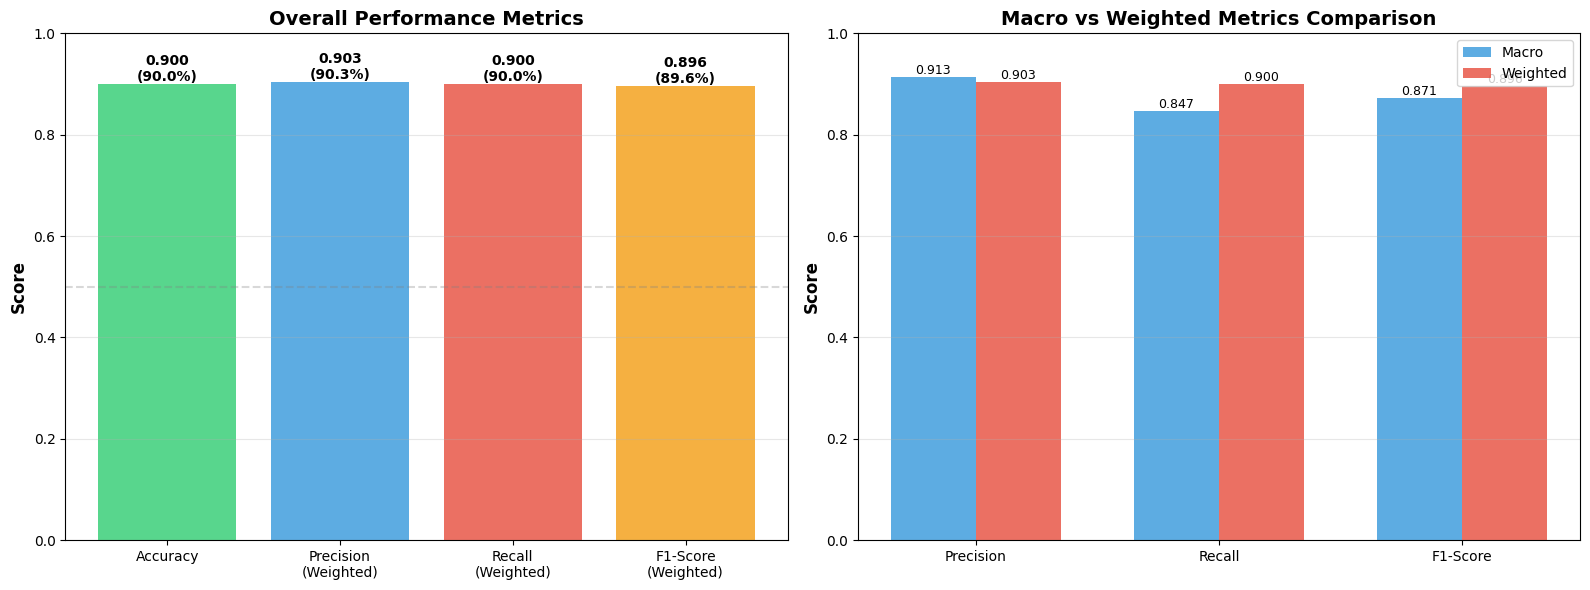

✅ Metrics visualization created!


In [15]:
# Visualize Metrics Comparison
print("🎨 Creating metrics visualization...\n")

import matplotlib.pyplot as plt

# Create metrics comparison bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Overall Metrics
metrics_names = ['Accuracy', 'Precision\n(Weighted)', 'Recall\n(Weighted)', 'F1-Score\n(Weighted)']
metrics_values = [accuracy, precision_weighted, recall_weighted, f1_weighted]

bars1 = ax1.bar(metrics_names, metrics_values, color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'], alpha=0.8)
ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('Overall Performance Metrics', fontsize=14, fontweight='bold')
ax1.set_ylim([0, 1])
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3, label='50% baseline')
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}\n({height*100:.1f}%)',
             ha='center', va='bottom', fontweight='bold')

# Plot 2: Macro vs Weighted Metrics
metrics_comparison = {
    'Precision': [precision_macro, precision_weighted],
    'Recall': [recall_macro, recall_weighted],
    'F1-Score': [f1_macro, f1_weighted]
}

x = np.arange(len(metrics_comparison))
width = 0.35

bars2_1 = ax2.bar(x - width/2, [v[0] for v in metrics_comparison.values()], 
                   width, label='Macro', color='#3498db', alpha=0.8)
bars2_2 = ax2.bar(x + width/2, [v[1] for v in metrics_comparison.values()], 
                   width, label='Weighted', color='#e74c3c', alpha=0.8)

ax2.set_ylabel('Score', fontsize=12, fontweight='bold')
ax2.set_title('Macro vs Weighted Metrics Comparison', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics_comparison.keys())
ax2.set_ylim([0, 1])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars2_1, bars2_2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.3f}',
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("✅ Metrics visualization created!")

In [16]:
# Detailed Classification Report
print("📊 DETAILED CLASSIFICATION REPORT")
print("="*80 + "\n")

# Generate classification report
report = classification_report(y_true, y_pred, labels=unique_labels, zero_division=0, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Display full report
print(classification_report(y_true, y_pred, labels=unique_labels, zero_division=0))

# Convert to DataFrame for better visualization
print("\n📈 Per-Class Metrics Summary:")
print(report_df.round(4))

# Show best and worst performing classes (only if there are many labels)
# Note: For status classification (NORMAL/SUSPICIOUS), we typically have 2-3 labels only
if len(unique_labels) > 5:
    print("\n🏆 TOP 5 BEST PERFORMING CLASSES (by F1-score):")
    # Filter out summary rows (accuracy, macro avg, weighted avg)
    class_rows = report_df[~report_df.index.isin(['accuracy', 'macro avg', 'weighted avg'])]
    class_metrics = class_rows.sort_values('f1-score', ascending=False)
    print(class_metrics.head(5)[['precision', 'recall', 'f1-score', 'support']].round(4))
    
    print("\n⚠️ TOP 5 WORST PERFORMING CLASSES (by F1-score):")
    print(class_metrics.tail(5)[['precision', 'recall', 'f1-score', 'support']].round(4))
elif len(unique_labels) > 0:
    print(f"\n📊 Status Classification Summary ({len(unique_labels)} classes):")
    # Show all classes for small number of labels
    class_rows = report_df[~report_df.index.isin(['accuracy', 'macro avg', 'weighted avg'])]
    if len(class_rows) > 0:
        print(class_rows[['precision', 'recall', 'f1-score', 'support']].round(4))

📊 DETAILED CLASSIFICATION REPORT

              precision    recall  f1-score   support

      NORMAL       0.89      0.98      0.93      1400
  SUSPICIOUS       0.94      0.71      0.81       600

    accuracy                           0.90      2000
   macro avg       0.91      0.85      0.87      2000
weighted avg       0.90      0.90      0.90      2000


📈 Per-Class Metrics Summary:
              precision  recall  f1-score  support
NORMAL           0.8891  0.9793    0.9320   1400.0
SUSPICIOUS       0.9367  0.7150    0.8110    600.0
accuracy         0.9000  0.9000    0.9000      0.9
macro avg        0.9129  0.8471    0.8715   2000.0
weighted avg     0.9034  0.9000    0.8957   2000.0

📊 Status Classification Summary (2 classes):
            precision  recall  f1-score  support
NORMAL         0.8891  0.9793     0.932   1400.0
SUSPICIOUS     0.9367  0.7150     0.811    600.0


🎨 Creating confusion matrix visualization...



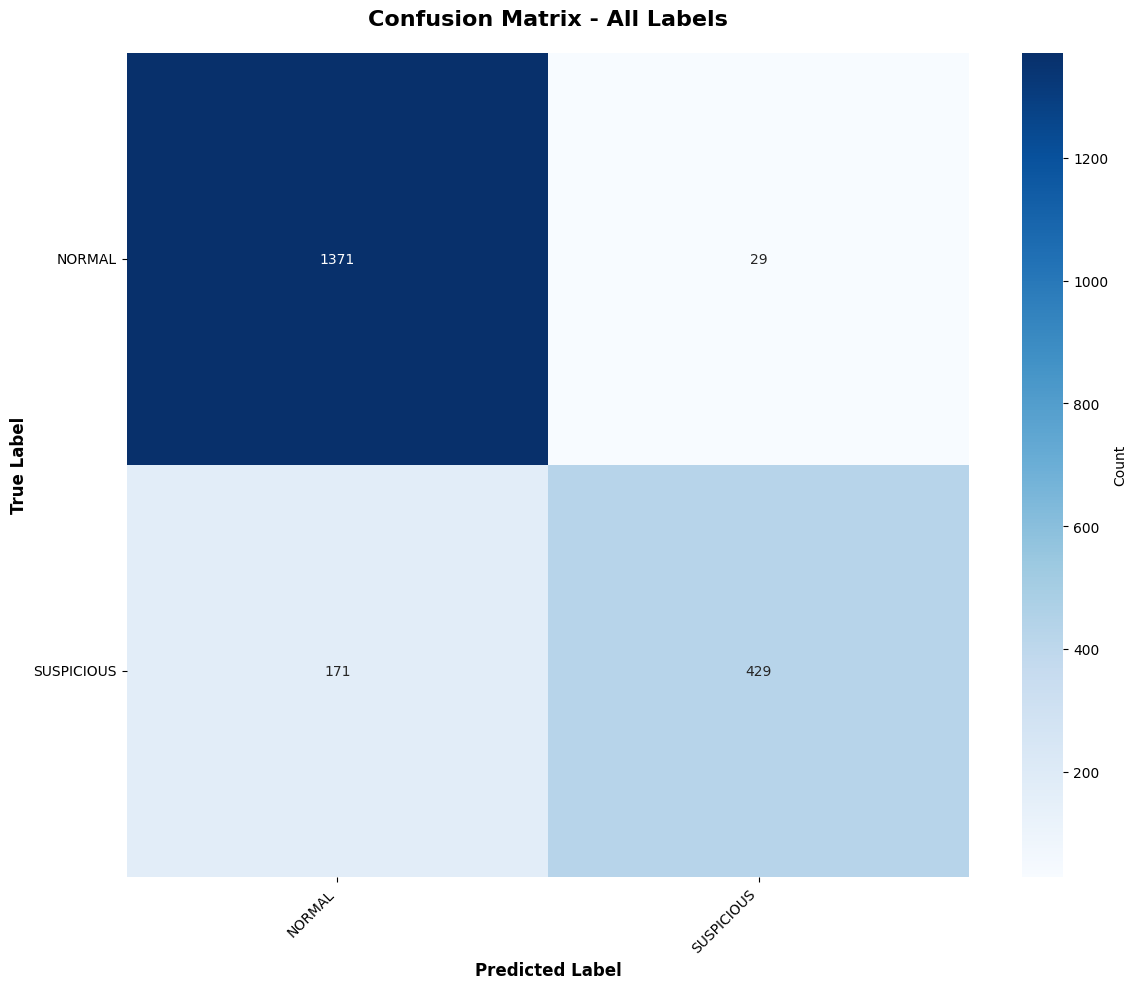

✅ Confusion matrix visualization created!


In [17]:
# Visualize Confusion Matrix
print("🎨 Creating confusion matrix visualization...\n")

import matplotlib.pyplot as plt
import seaborn as sns

# Create figure
fig, ax = plt.subplots(figsize=(max(12, len(unique_labels)), max(10, len(unique_labels))))

# If too many labels, show a subset or use different visualization
if len(unique_labels) > 20:
    print(f"⚠️ Large number of labels ({len(unique_labels)}). Showing top 20 most frequent...")
    
    # Get top N most frequent labels
    from collections import Counter
    label_counts = Counter(y_true)
    top_labels = [label for label, _ in label_counts.most_common(20)]
    
    # Filter confusion matrix for top labels
    label_indices = [unique_labels.index(label) for label in top_labels]
    conf_matrix_subset = conf_matrix[np.ix_(label_indices, label_indices)]
    
    # Plot subset
    sns.heatmap(conf_matrix_subset, 
                annot=True, 
                fmt='d', 
                cmap='Blues',
                xticklabels=top_labels,
                yticklabels=top_labels,
                ax=ax,
                cbar_kws={'label': 'Count'})
    
    plt.title(f'Confusion Matrix (Top 20 Labels)\nTotal Labels: {len(unique_labels)}', 
              fontsize=16, fontweight='bold', pad=20)
else:
    # Plot full confusion matrix
    sns.heatmap(conf_matrix, 
                annot=True, 
                fmt='d', 
                cmap='Blues',
                xticklabels=unique_labels,
                yticklabels=unique_labels,
                ax=ax,
                cbar_kws={'label': 'Count'})
    
    plt.title('Confusion Matrix - All Labels', fontsize=16, fontweight='bold', pad=20)

plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("✅ Confusion matrix visualization created!")